# Show the bivariate analysis usage

In [ ]:
!git clone https://github.com/jackmat/bivariate_analysis.git
!pip install jupyter_bokeh


fatal: destination path 'bivariate_analysis' already exists and is not an empty directory.


You should consider upgrading via the 'C:\Users\sansca\.pyenv\pyenv-win\versions\3.10.4\python.exe -m pip install --upgrade pip' command.


In [ ]:
from  bivariate_analysis.src.bivariate_functions import categorize_into_deciles_with_stats, plot_data_by_varname, plot_interactive_panel
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from google.colab import output
# output.enable_custom_widget_manager()

## Example 1: iris dataset

In [ ]:

# Load the iris dataset
df = pd.DataFrame(data=load_iris().data, columns=load_iris().feature_names)

# Define the target column and columns to drop
target_column = "sepal length (cm)"
drop_cols = []

# Validate input columns
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' is not in the DataFrame.")
for col in drop_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' in drop_cols is not in the DataFrame.")

# Initialize an empty DataFrame to store results
bivariate_statistics = pd.DataFrame()
visualizations = {}

# Identify columns to evaluate
cols_to_evaluate = list(set(df.columns) - set([target_column]) - set(drop_cols))

# Analyze each column
for column in cols_to_evaluate:
    result = categorize_into_deciles_with_stats(
        df, column, target_column, n_deciles=10, f_decile_tree=True
    )
    bivariate_statistics = pd.concat([bivariate_statistics, result], ignore_index=True)

display(bivariate_statistics)


22
43
23


,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,sepal length (cm)_mean,sepal length (cm)_std,sepal length (cm)_median,sepal length (cm)_25%,sepal length (cm)_75%,n,n_percentage,gen_sepal length (cm)_mean,discr,max_discr,x_string
0,0,petal width (cm),0.1,0.3,0.20,0.200,0.20,4.953659,0.353622,5.00,4.700,5.100,41,27.333333,5.843333,0.152255,0.158408,[0-0]
1,1,petal width (cm),0.4,1.1,1.00,0.400,1.00,5.331579,0.326688,5.40,5.050,5.550,19,12.666667,5.843333,0.087579,0.158408,[0-1]
2,2,petal width (cm),1.2,1.3,1.30,1.225,1.30,5.855556,0.339935,5.70,5.600,6.100,18,12.000000,5.843333,0.002092,0.158408,[1-1]
3,3,petal width (cm),1.4,1.7,1.50,1.400,1.50,6.226923,0.548130,6.25,6.000,6.675,26,17.333333,5.843333,0.065646,0.158408,[1-2]
4,4,petal width (cm),1.8,1.9,1.80,1.800,1.90,6.382353,0.505266,6.30,6.000,6.500,17,11.333333,5.843333,0.092245,0.158408,[2-2]
5,5,petal width (cm),2.0,2.5,2.20,2.100,2.30,6.768966,0.616501,6.70,6.400,7.100,29,19.333333,5.843333,0.158408,0.158408,[2-2]
6,0,petal length (cm),1.0,1.4,1.40,1.300,1.40,4.895833,0.395055,4.90,4.600,5.100,24,16.000000,5.843333,0.162151,0.227670,[1-1]
7,1,petal length (cm),1.5,3.3,1.60,1.500,1.70,5.096552,0.266569,5.10,4.900,5.200,29,19.333333,5.843333,0.127801,0.227670,[2-3]
8,2,petal length (cm),3.5,4.2,4.00,3.875,4.10,5.640000,0.250053,5.65,5.500,5.800,20,13.333333,5.843333,0.034797,0.227670,[4-4]
9,3,petal length (cm),4.3,4.6,4.50,4.400,4.50,6.064706,0.497420,6.20,5.700,6.400,17,11.333333,5.843333,0.037885,0.227670,[4-5]


### What are the bins that are most discriminant than 10% ?

In [ ]:
threshold = 0.1 # 10%
bivariate_statistics[bivariate_statistics["discr"]>threshold]

,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,sepal length (cm)_mean,sepal length (cm)_std,sepal length (cm)_median,sepal length (cm)_25%,sepal length (cm)_75%,n,n_percentage,gen_sepal length (cm)_mean,discr,max_discr,x_string
0,0,petal width (cm),0.1,0.3,0.2,0.20,0.20,4.953659,0.353622,5.0,4.70,5.10,41,27.333333,5.843333,0.152255,0.158408,[0-0]
5,5,petal width (cm),2.0,2.5,2.2,2.10,2.30,6.768966,0.616501,6.7,6.40,7.10,29,19.333333,5.843333,0.158408,0.158408,[2-2]
6,0,petal length (cm),1.0,1.4,1.4,1.30,1.40,4.895833,0.395055,4.9,4.60,5.10,24,16.000000,5.843333,0.162151,0.227670,[1-1]
7,1,petal length (cm),1.5,3.3,1.6,1.50,1.70,5.096552,0.266569,5.1,4.90,5.20,29,19.333333,5.843333,0.127801,0.227670,[2-3]
11,5,petal length (cm),5.2,5.6,5.5,5.35,5.60,6.466667,0.222539,6.4,6.35,6.60,15,10.000000,5.843333,0.106674,0.227670,[5-6]
12,6,petal length (cm),5.7,6.9,6.0,5.80,6.35,7.173684,0.471218,7.2,6.75,7.65,19,12.666667,5.843333,0.227670,0.227670,[6-7]


As an example the first decile X_decile being 0 has a 15.2% discrimination. This contains the values for petal witdh between 0.1 and 0.3

### What are the variables which at least contain some part being more discriminant than 10%.

In [ ]:
threshold = 0.1 # 10%
bivariate_statistics[bivariate_statistics["max_discr"]>threshold][["varname", "max_discr"]].drop_duplicates()

,varname,max_discr
0,petal width (cm),0.158408
6,petal length (cm),0.227670


### Can you plot the different cases ?

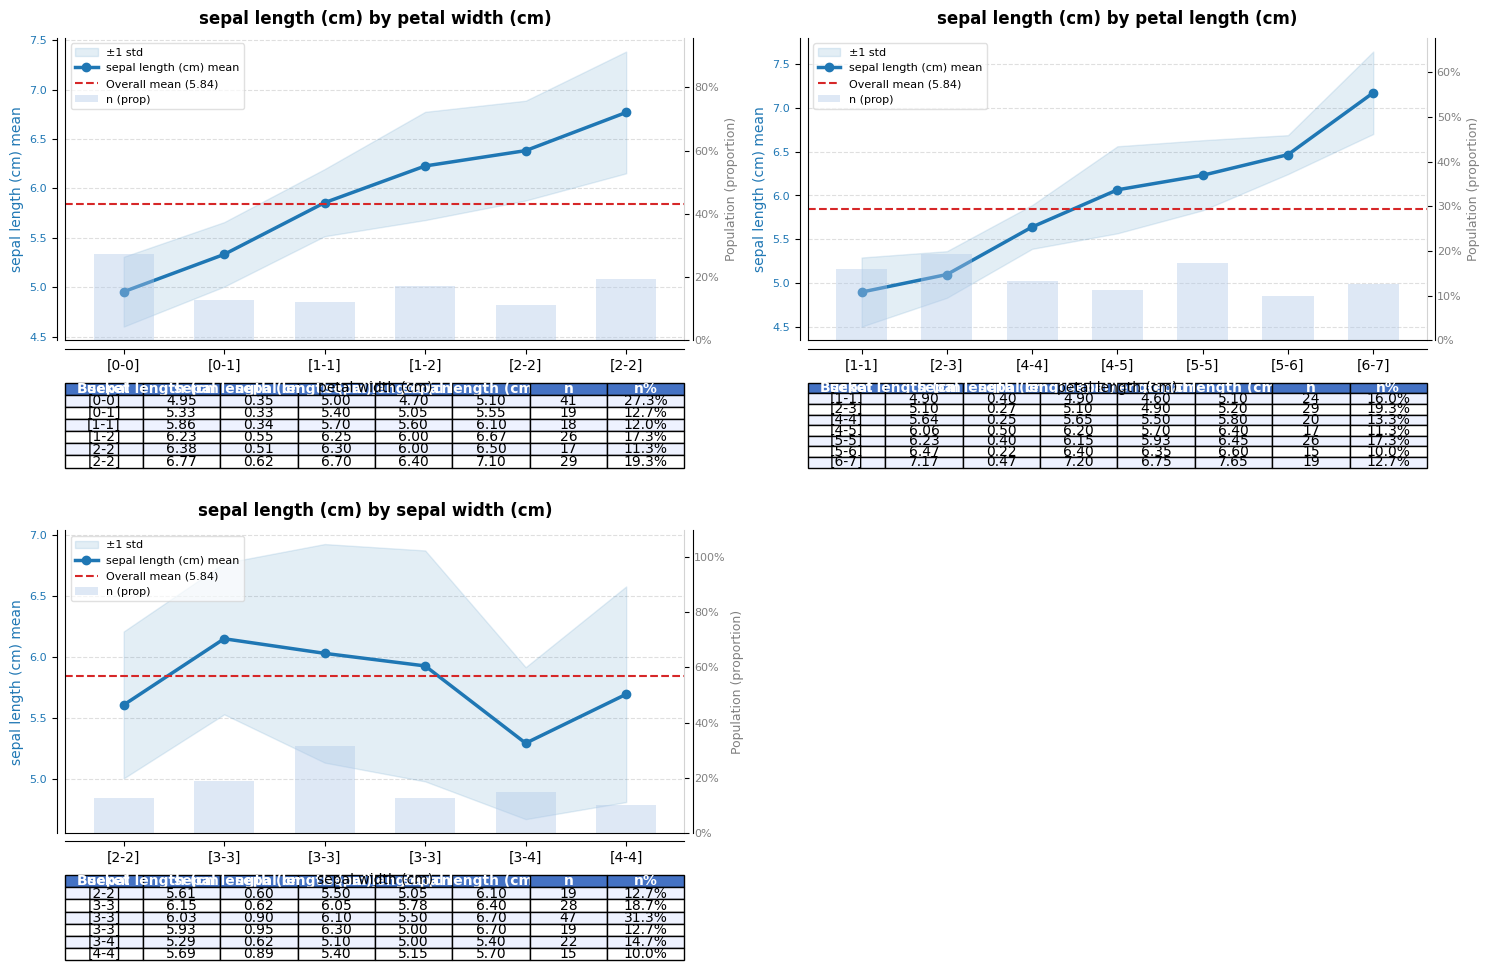

In [ ]:

# Generate visualizations in a grid layout
n_cols = len(cols_to_evaluate)
n_rows = (n_cols + 1) // 2
fig, axes = plt.subplots(2, n_rows, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(cols_to_evaluate):
    plot_data_by_varname(axes[i], bivariate_statistics, var, target_column)

# Hide unused subplots
for j in range(len(cols_to_evaluate), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## Example 2: mtcars dataset

In [ ]:
# Load the mtcars dataset
df = sns.load_dataset('mpg').dropna()  # Using mpg as a car-related dataset
display(df)
# Define the target column and columns to drop
target_column = "mpg"  # Miles per gallon as the target column
drop_cols = ["name"]

# Validate input columns
if target_column not in df.columns:
    raise ValueError(f"Target column '{target_column}' is not in the DataFrame.")
for col in drop_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' in drop_cols is not in the DataFrame.")
df["origin"]=df["origin"].astype(str)

# Initialize an empty DataFrame to store results
bivariate_statistics = pd.DataFrame()
visualizations = {}

# Identify columns to evaluate
cols_to_evaluate = list(set(df.columns) - set([target_column]) - set(drop_cols))

# Analyze each column
for column in cols_to_evaluate:
    print(f"column: {column}")
    result = categorize_into_deciles_with_stats(
        df, column, target_column, n_deciles=10, f_decile_tree=True
    )
    bivariate_statistics = pd.concat([bivariate_statistics, result], ignore_index=True)

display(bivariate_statistics)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


column: displacement
81
column: acceleration
95
column: model_year
13
column: origin
column: horsepower
93
column: cylinders
5
column: weight
346


,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,mpg_mean,mpg_std,mpg_median,mpg_25%,mpg_75%,n,n_percentage,gen_mpg_mean,discr,max_discr,x_string
0,0,displacement,68.0,91.0,86.00,79.000,90.00,33.063636,6.171931,32.00,29.900,37.250,55,14.030612,23.445918,0.410209,0.410209,[68-91]
1,1,displacement,96.0,112.0,98.00,97.000,105.00,30.116923,4.573448,29.90,27.000,33.700,65,16.581633,23.445918,0.284527,0.410209,[96-112]
2,2,displacement,113.0,135.0,121.00,119.000,122.00,25.720755,4.956323,24.00,22.000,28.000,53,13.520408,23.445918,0.097025,0.410209,[113-135]
3,3,displacement,140.0,183.0,151.00,140.000,156.00,24.883673,3.957448,25.10,23.000,27.000,49,12.500000,23.445918,0.061322,0.410209,[140-183]
4,4,displacement,198.0,267.0,232.00,225.000,250.00,19.319444,3.059211,19.00,18.000,20.500,72,18.367347,23.445918,0.176000,0.410209,[198-267]
5,5,displacement,302.0,318.0,305.00,302.500,318.00,15.290476,2.466142,15.00,14.000,17.375,42,10.714286,23.445918,0.347841,0.410209,[302-318]
6,6,displacement,340.0,455.0,360.00,350.000,400.00,14.267857,2.655704,14.00,13.000,15.000,56,14.285714,23.445918,0.391457,0.410209,[340-455]
7,0,acceleration,8.0,12.1,11.35,10.625,11.90,15.609524,4.735018,14.00,13.000,16.000,42,10.714286,23.445918,0.334233,0.334233,[8-12]
8,1,acceleration,12.2,13.7,13.00,12.800,13.50,18.735714,6.049506,17.50,14.000,21.500,56,14.285714,23.445918,0.200897,0.334233,[12-14]
9,2,acceleration,13.8,15.3,14.50,14.200,14.90,25.014444,7.988750,25.00,18.125,30.800,90,22.959184,23.445918,0.066900,0.334233,[14-15]


### What are the bins that are most discriminant than 30% ?

In [ ]:
threshold = 0.3 # 10%
bivariate_statistics[bivariate_statistics["discr"]>threshold]

,X_decile,varname,X_min,X_max,X_median,X_25%,X_75%,mpg_mean,mpg_std,mpg_median,mpg_25%,mpg_75%,n,n_percentage,gen_mpg_mean,discr,max_discr,x_string
0,0,displacement,68.0,91.0,86.00,79.000,90.0,33.063636,6.171931,32.00,29.90,37.250,55,14.030612,23.445918,0.410209,0.410209,[68-91]
5,5,displacement,302.0,318.0,305.00,302.500,318.0,15.290476,2.466142,15.00,14.00,17.375,42,10.714286,23.445918,0.347841,0.410209,[302-318]
6,6,displacement,340.0,455.0,360.00,350.000,400.0,14.267857,2.655704,14.00,13.00,15.000,56,14.285714,23.445918,0.391457,0.410209,[340-455]
7,0,acceleration,8.0,12.1,11.35,10.625,11.9,15.609524,4.735018,14.00,13.00,16.000,42,10.714286,23.445918,0.334233,0.334233,[8-12]
24,80,model_year,NaN,NaN,NaN,NaN,NaN,33.803704,6.885854,32.70,29.80,37.650,27,6.887755,23.445918,0.441773,0.441773,80
26,82,model_year,NaN,NaN,NaN,NaN,NaN,32.000000,5.232524,32.00,27.25,36.000,30,7.653061,23.445918,0.364843,0.441773,82
30,0,horsepower,46.0,70.0,65.00,60.000,68.0,33.666197,5.076246,33.00,30.00,37.000,71,18.112245,23.445918,0.435909,0.435909,[46-70]
35,5,horsepower,129.0,150.0,145.00,139.000,150.0,15.737736,3.132597,15.00,14.00,17.000,53,13.520408,23.445918,0.328764,0.435909,[129-150]
36,6,horsepower,152.0,230.0,175.00,165.000,198.0,13.524444,1.888501,14.00,12.00,15.000,45,11.479592,23.445918,0.423164,0.435909,[152-230]
37,8,cylinders,NaN,NaN,NaN,NaN,NaN,14.963107,2.836284,14.00,13.00,16.000,103,26.275510,23.445918,0.361803,0.361803,8


### What are the variables which at least contain some part being more discriminant than 10%.

In [ ]:
import numpy as np
threshold = 0.1 # 10%
print(f"The cases columns with info being discriminant more than {int(threshold*100)}% are:")
display(bivariate_statistics[bivariate_statistics["max_discr"]>threshold][["varname", "max_discr"]].drop_duplicates()
)
varname_list = bivariate_statistics[bivariate_statistics["max_discr"]>threshold][["varname", "max_discr"]].drop_duplicates().varname.tolist()

The cases columns with info being discriminant more than 10% are:


,varname,max_discr
0,displacement,0.410209
7,acceleration,0.334233
14,model_year,0.441773
27,origin,0.298761
30,horsepower,0.435909
37,cylinders,0.361803
42,weight,0.429761


### Can you plot the different cases ?

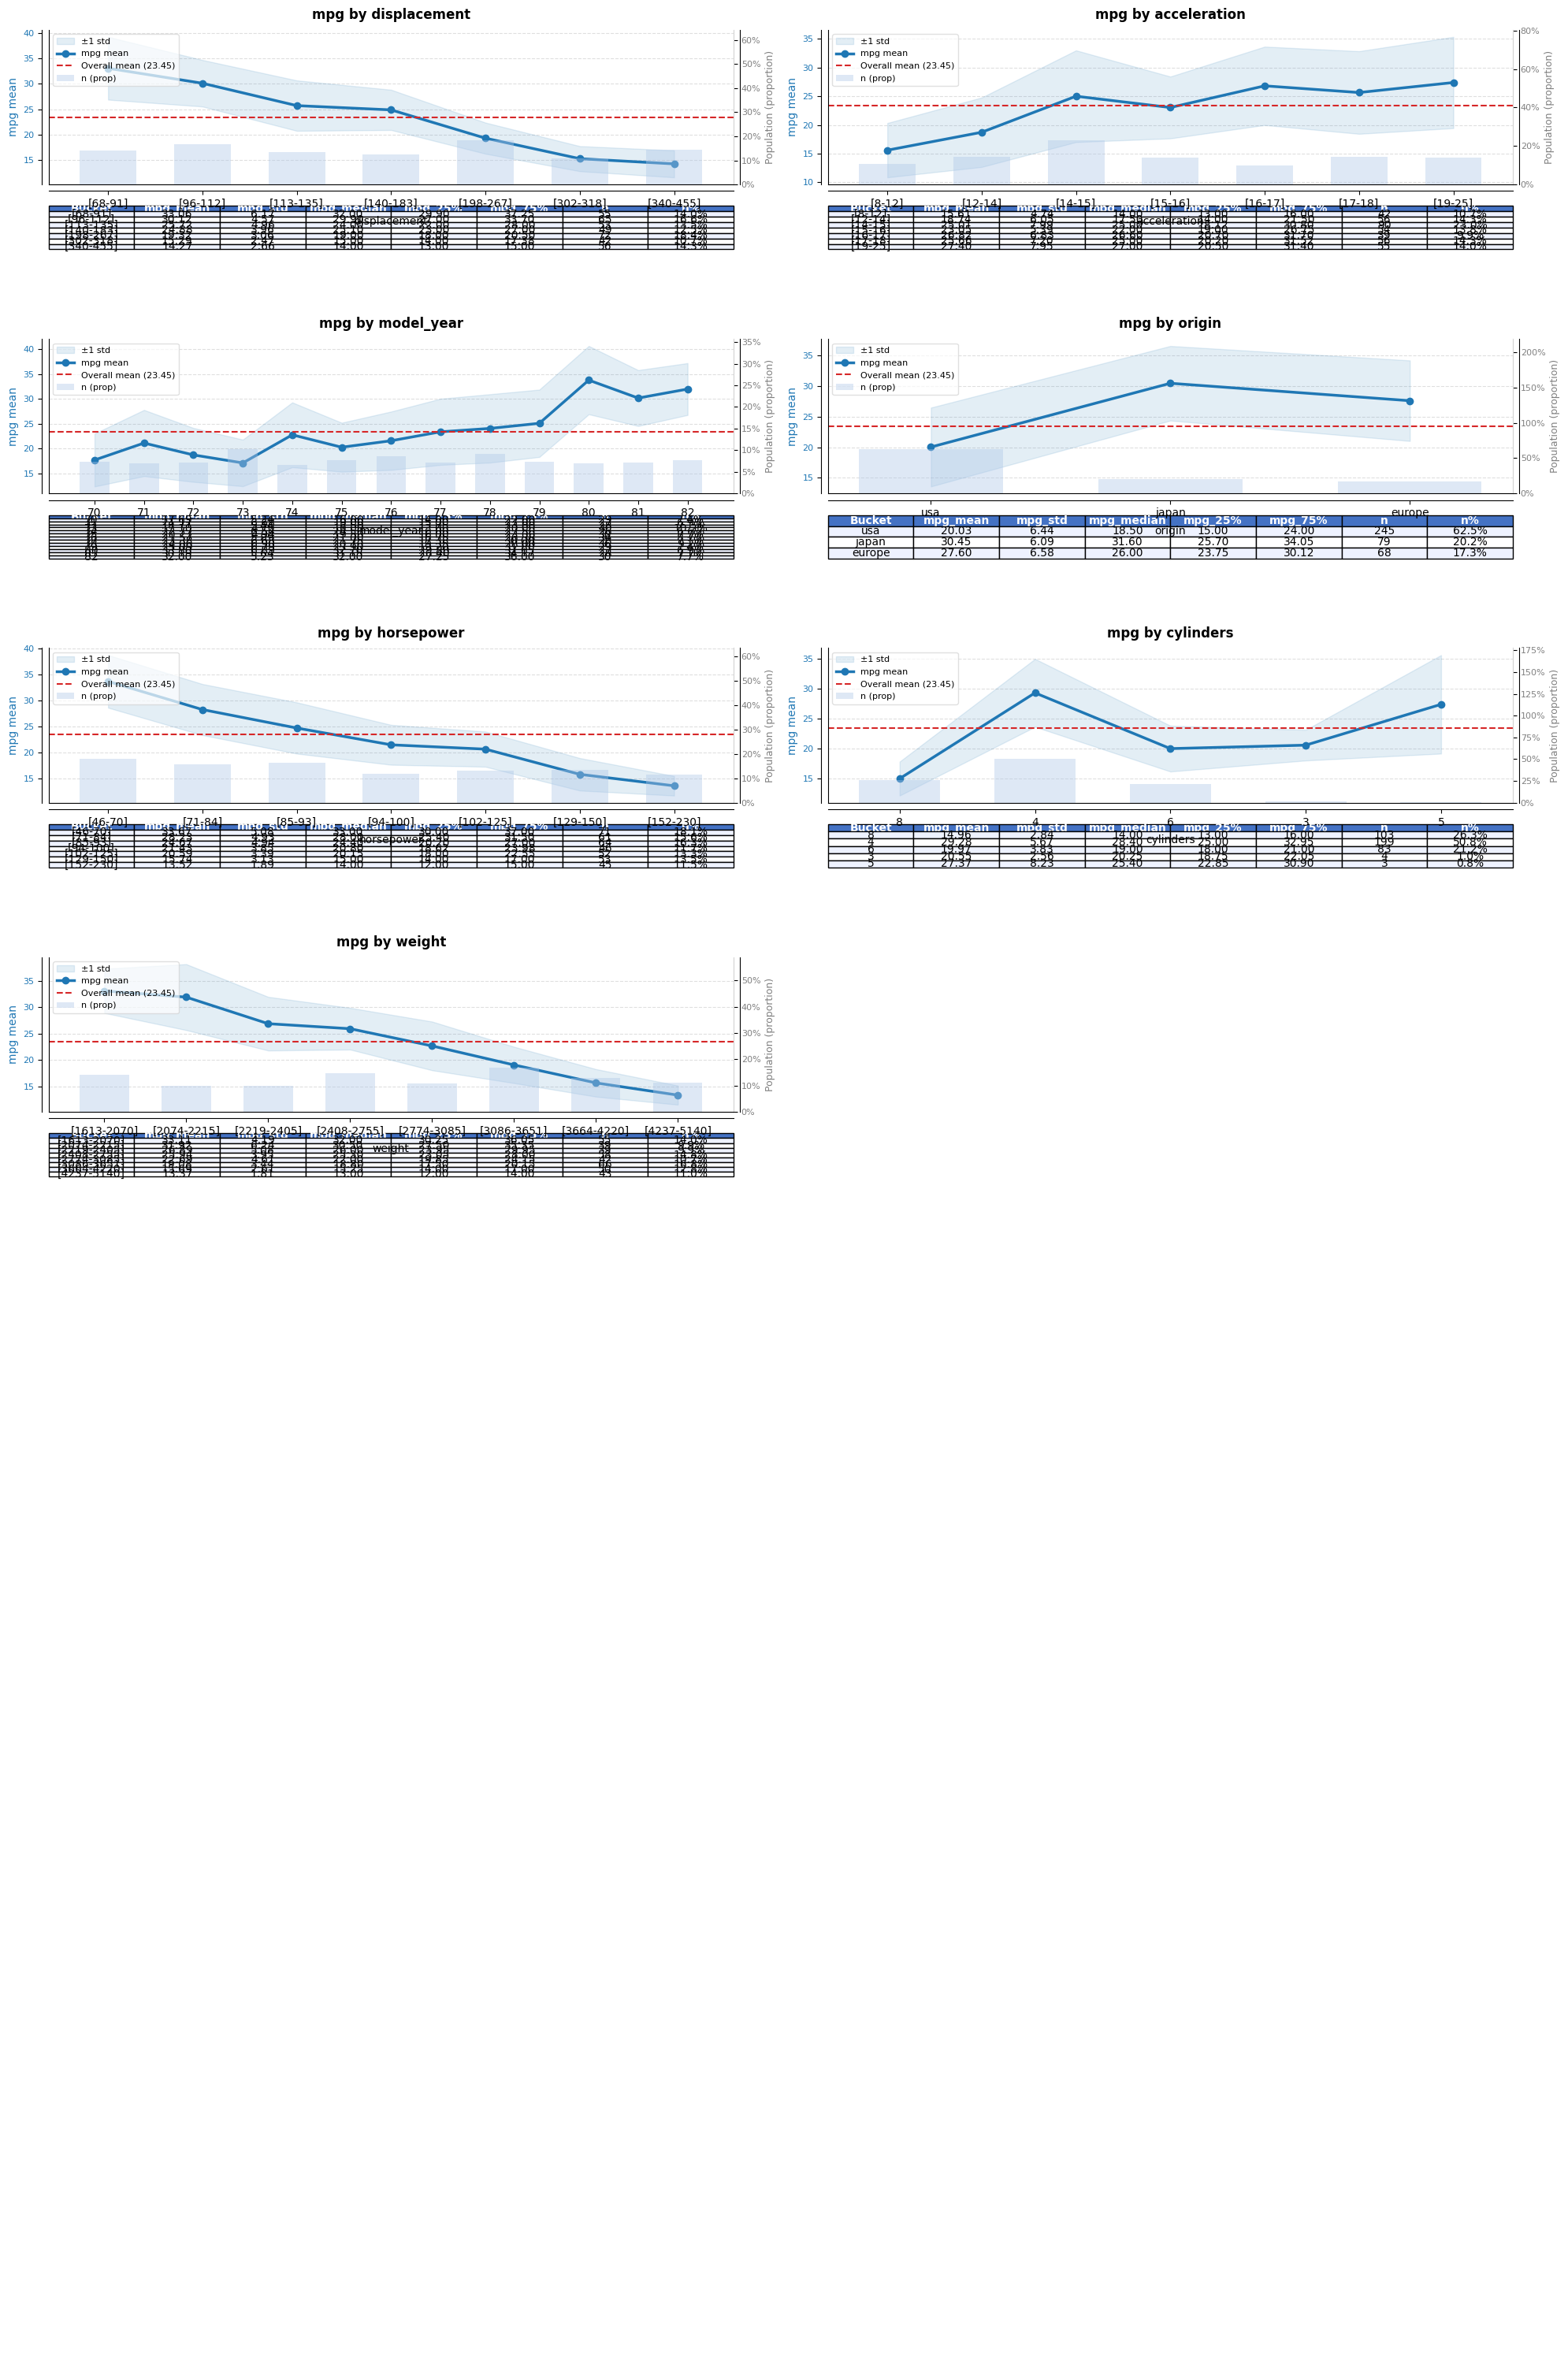

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Generate visualizations in a grid layout
n_cols = len(varname_list)
n_rows = (n_cols + 1) # // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(20, 30))
axes = axes.flatten()

for i, var in enumerate(varname_list):
    plot_data_by_varname(axes[i], bivariate_statistics, var, target_column)

# Hide unused subplots
for j in range(len(cols_to_evaluate), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
fig.subplots_adjust(hspace=1)  # Increase vertical spacing if needed
plt.show()

## Interactive Panel — max_discr filter + variable selector

Two controls let you explore manually:

| Widget | What it does |
|---|---|
| **Min max_discr slider** | Raises the minimum discrepancy threshold — only variables with `max_discr ≥ threshold` appear in the dropdown. Drag right to keep only the most discriminating variables. |
| **Variable dropdown** | Choose any surviving variable. Options are sorted by `max_discr` (highest first) and show the score next to the name, e.g. `cylinders  (discr=0.421)`. |

The chart updates immediately whenever either control changes.

In [ ]:
# Then your call:
plot_interactive_panel(bivariate_statistics, 'mpg')